In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import random
import PIL
from PIL import Image
import os
import numpy as np
import pandas as pd
import pickle
import tarfile
from tqdm import tqdm_notebook as tqdm
#tqdm().pandas()
import tensorflow
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import pydicom
import cv2

2025-07-01 19:52:07.670114: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-07-01 19:52:07.934651: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-07-01 19:52:07.934730: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-07-01 19:52:07.981618: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-01 19:52:08.092485: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-07-01 19:52:08.093886: I tensorflow/core/platform/cpu_feature_guard.cc:1

In [6]:
img = "gs://BUCKET_NAME/dicom/dicom/id"
img.split('/')[5]

'id'

In [2]:
data_dir = "/home/gulfairus/.database/lung_cancer/data/raw"

In [3]:
train_df = pd.read_csv(os.path.join(data_dir, "miccai2023_nih-cxr-lt_labels_train.csv"))
val_df = pd.read_csv(os.path.join(data_dir, "miccai2023_nih-cxr-lt_labels_val.csv"))
test_df = pd.read_csv(os.path.join(data_dir, "miccai2023_nih-cxr-lt_labels_test.csv"))

In [ ]:
def check_for_leakage(df1, df2, patient_col):

    df1_patients_unique = set(df1[patient_col])
    df2_patients_unique = set(df2[patient_col])

    patients_in_both_groups = list(df1_patients_unique.intersection(df2_patients_unique))

    if len(patients_in_both_groups) == 0:
        leakage = False
    else:
        leakage = True

    return leakage

In [6]:
check_for_leakage(train_df, val_df, 'subj_id')

False

In [7]:
check_for_leakage(test_df, val_df, 'subj_id')

False

In [8]:
check_for_leakage(train_df, test_df, 'subj_id')

False

In [10]:
train_df.head()

,id,Atelectasis,Cardiomegaly,Consolidation,Edema,Effusion,Emphysema,Fibrosis,Hernia,Infiltration,...,Pleural Thickening,Pneumonia,Pneumothorax,Pneumoperitoneum,Pneumomediastinum,Subcutaneous Emphysema,Tortuous Aorta,Calcification of the Aorta,No Finding,subj_id
0,00000001_000.png,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,00000001_001.png,0,1,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,00000001_002.png,0,1,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,00000002_000.png,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,2
4,00000004_000.png,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4


In [4]:
id = train_df['id'].apply(lambda x: x.split('.')[0] + '.dcm')
train_df['id'] = id

In [5]:
train_df.head()

,id,Atelectasis,Cardiomegaly,Consolidation,Edema,Effusion,Emphysema,Fibrosis,Hernia,Infiltration,...,Pleural Thickening,Pneumonia,Pneumothorax,Pneumoperitoneum,Pneumomediastinum,Subcutaneous Emphysema,Tortuous Aorta,Calcification of the Aorta,No Finding,subj_id
0,00000001_000.dcm,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,00000001_001.dcm,0,1,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,00000001_002.dcm,0,1,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,00000002_000.dcm,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,2
4,00000004_000.dcm,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4


In [18]:
pixels = [1,2,3,4,5,6,7,8,9,10]

In [16]:
pixels = np.stack(pixels)

In [9]:
train_id = list(train_df["id"].values)
train_id

['00000001_000.dcm',
 '00000001_001.dcm',
 '00000001_002.dcm',
 '00000002_000.dcm',
 '00000004_000.dcm',
 '00000005_000.dcm',
 '00000005_001.dcm',
 '00000005_002.dcm',
 '00000005_003.dcm',
 '00000005_004.dcm',
 '00000005_005.dcm',
 '00000005_006.dcm',
 '00000005_007.dcm',
 '00000006_000.dcm',
 '00000007_000.dcm',
 '00000008_000.dcm',
 '00000008_001.dcm',
 '00000008_002.dcm',
 '00000010_000.dcm',
 '00000011_000.dcm',
 '00000011_001.dcm',
 '00000011_002.dcm',
 '00000011_003.dcm',
 '00000011_004.dcm',
 '00000011_005.dcm',
 '00000011_006.dcm',
 '00000011_007.dcm',
 '00000011_008.dcm',
 '00000014_000.dcm',
 '00000015_000.dcm',
 '00000016_000.dcm',
 '00000017_000.dcm',
 '00000017_001.dcm',
 '00000017_002.dcm',
 '00000018_000.dcm',
 '00000019_000.dcm',
 '00000020_000.dcm',
 '00000020_001.dcm',
 '00000020_002.dcm',
 '00000021_000.dcm',
 '00000021_001.dcm',
 '00000022_000.dcm',
 '00000022_001.dcm',
 '00000023_000.dcm',
 '00000023_001.dcm',
 '00000023_002.dcm',
 '00000023_003.dcm',
 '00000023_00

In [26]:
labels = train_df.drop(columns=['id', 'subj_id'])
labels.head()

,Atelectasis,Cardiomegaly,Consolidation,Edema,Effusion,Emphysema,Fibrosis,Hernia,Infiltration,Mass,Nodule,Pleural Thickening,Pneumonia,Pneumothorax,Pneumoperitoneum,Pneumomediastinum,Subcutaneous Emphysema,Tortuous Aorta,Calcification of the Aorta,No Finding
0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
4,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0


In [15]:
list(labels.iloc[0])

[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

In [ ]:
labels = labels.apply(lambda x: x.to_list(), axis=1)

[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

In [29]:
labels.to_list()

[[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
 [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
 [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [38]:
import tensorflow as tf

# Create a simple dataset
data = tf.constant([1, 2, 3, 4, 5])
dataset = tf.data.Dataset.from_tensor_slices(data).batch(2).prefetch(tf.data.AUTOTUNE)

# Correct way to get elements
iterator = iter(dataset)
print(next(iterator))

tf.Tensor([1 2], shape=(2,), dtype=int32)


In [34]:
iterator = iter(dataset)
print(next(iterator))

tf.Tensor([1 2], shape=(2,), dtype=int32)


In [15]:
# Remove unnecesary elements
columns.remove('id')
columns.remove('No Finding')
columns.remove('subj_id')
# Get the total classes
print(f"There are {len(columns)} columns of labels for these conditions: {columns}")

There are 19 columns of labels for these conditions: ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'Nodule', 'Pleural Thickening', 'Pneumonia', 'Pneumothorax', 'Pneumoperitoneum', 'Pneumomediastinum', 'Subcutaneous Emphysema', 'Tortuous Aorta', 'Calcification of the Aorta']


In [17]:
columns

['Atelectasis',
 'Cardiomegaly',
 'Consolidation',
 'Edema',
 'Effusion',
 'Emphysema',
 'Fibrosis',
 'Hernia',
 'Infiltration',
 'Mass',
 'Nodule',
 'Pleural Thickening',
 'Pneumonia',
 'Pneumothorax',
 'Pneumoperitoneum',
 'Pneumomediastinum',
 'Subcutaneous Emphysema',
 'Tortuous Aorta',
 'Calcification of the Aorta']

In [16]:
# Print out the number of positive labels for each class
for column in columns:
    print(f"The class {column} has {train_df[column].sum()} samples")

The class Atelectasis has 7587 samples
The class Cardiomegaly has 1590 samples
The class Consolidation has 2626 samples
The class Edema has 1283 samples
The class Effusion has 7919 samples
The class Emphysema has 1327 samples
The class Fibrosis has 1138 samples
The class Hernia has 130 samples
The class Infiltration has 12739 samples
The class Mass has 3689 samples
The class Nodule has 4359 samples
The class Pleural Thickening has 1998 samples
The class Pneumonia has 806 samples
The class Pneumothorax has 2432 samples
The class Pneumoperitoneum has 214 samples
The class Pneumomediastinum has 88 samples
The class Subcutaneous Emphysema has 957 samples
The class Tortuous Aorta has 598 samples
The class Calcification of the Aorta has 368 samples


In [10]:
dicom_dir = "/mnt/c/Users/User/Downloads/dicom/dicom"

Display Random Images


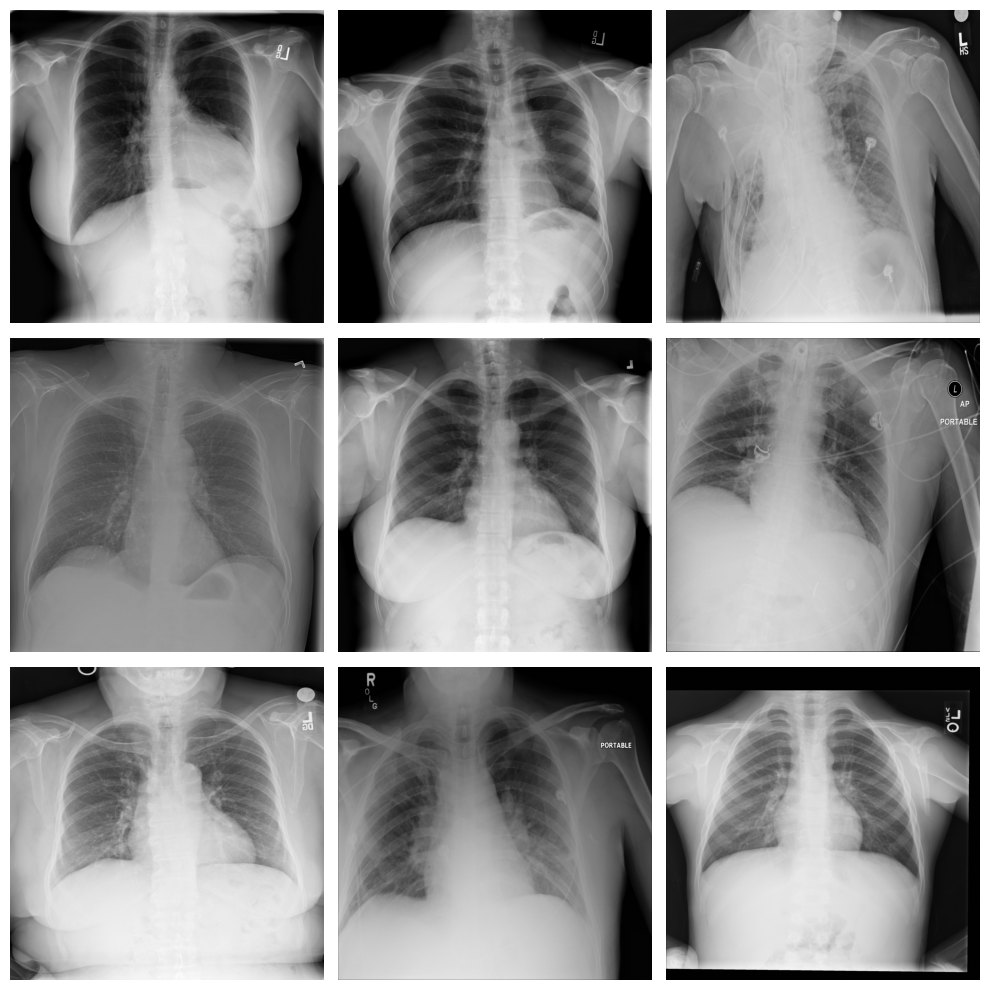

In [11]:
# Extract numpy values from Image column in data frame
images = train_df['id'].values

# Extract 9 random images from it
random_images = [np.random.choice(images) for i in range(9)]

# Location of the image dir
img_dir = dicom_dir

print('Display Random Images')

# Adjust the size of your images
plt.figure(figsize=(10,10))

# Iterate and plot random images
for i in range(9):
    plt.subplot(3, 3, i + 1)
    im = random_images[i].split('.')[0]
    im = im + '.dcm'
    img = pydicom.dcmread(os.path.join(img_dir, im))
    img = img.pixel_array
    plt.imshow(img, cmap='gray')
    plt.axis('off')

# Adjust subplot parameters to give specified padding
plt.tight_layout()

In [12]:
train_df[train_df['subj_id']==1]

,id,Atelectasis,Cardiomegaly,Consolidation,Edema,Effusion,Emphysema,Fibrosis,Hernia,Infiltration,...,Pleural Thickening,Pneumonia,Pneumothorax,Pneumoperitoneum,Pneumomediastinum,Subcutaneous Emphysema,Tortuous Aorta,Calcification of the Aorta,No Finding,subj_id
0,00000001_000.png,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,00000001_001.png,0,1,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,00000001_002.png,0,1,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


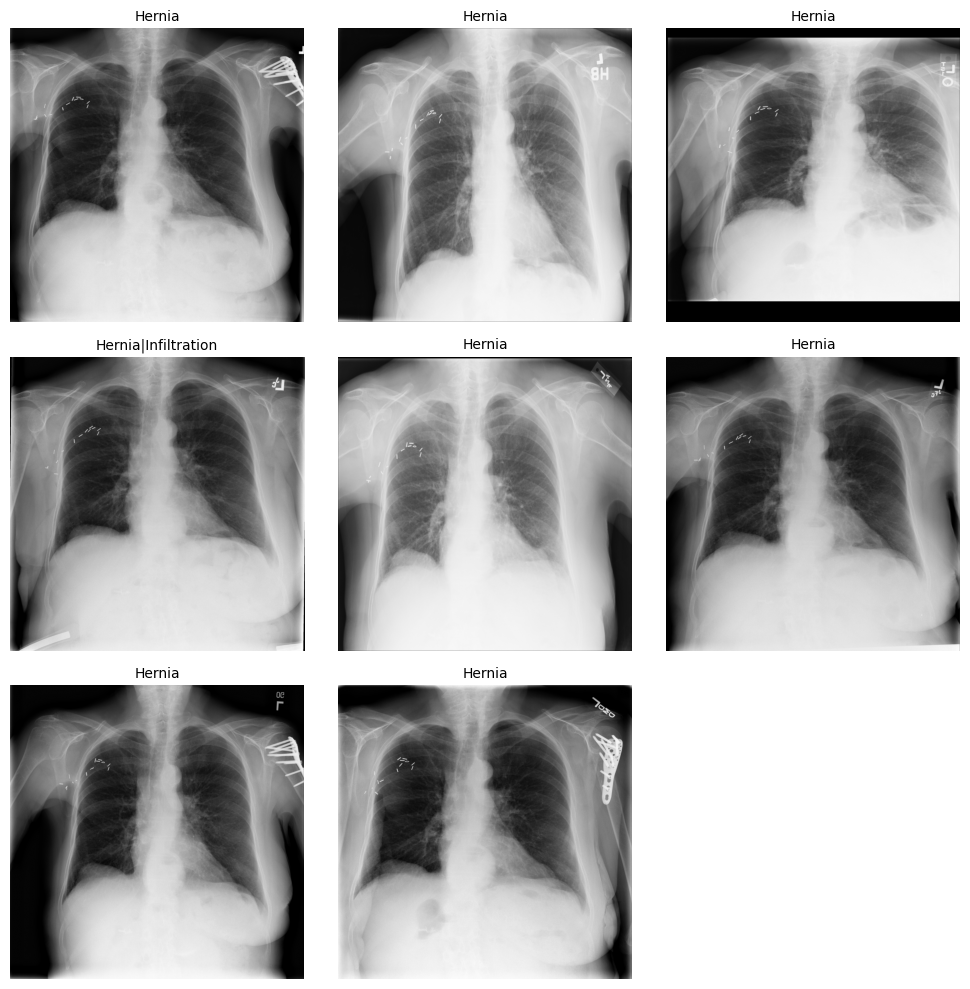

In [14]:
plt.figure(figsize=(10,10))
#dicom_files = ["00000001_000.dcm", "00000001_001.dcm", "00000001_002.dcm"]
dicom_files = ["00000003_000.dcm", "00000003_001.dcm", "00000003_002.dcm", "00000003_003.dcm", "00000003_004.dcm", "00000003_005.dcm", "00000003_006.dcm", "00000003_007.dcm"]
# Iterate and plot random images
for i in range(8):
    sp = plt.subplot(3, 3, i + 1)
    img = pydicom.dcmread(os.path.join(img_dir, dicom_files[i]))
    img_arr = img.pixel_array
    plt.imshow(img_arr, cmap='gray')
    sp.set_title(img.StudyDescription, fontsize=10)
    plt.axis('off')

# Adjust subplot parameters to give specified padding
plt.tight_layout()

(1024, 1024, 3)


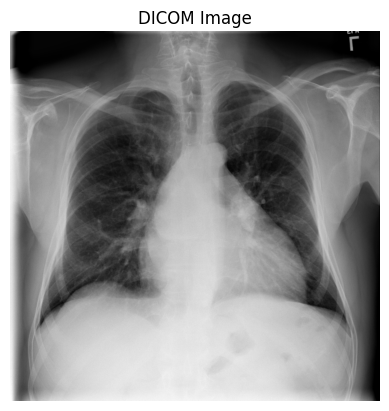

In [34]:
# Load the DICOM file
dicom_file = pydicom.dcmread(os.path.join(dicom_dir, "00000001_000.dcm"))
#print(dicom_file.get_private_item)
# Extract the pixel data
image = dicom_file.pixel_array
image = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
# Show the image using matplotlib
plt.imshow(image, cmap=plt.cm.gray)
print(image.shape)
#plt.imshow(image)
plt.title("DICOM Image")
plt.axis("off")
plt.show()

In [ ]:
# Initialize PyRadiomics extractor
extractor = featureextractor.RadiomicsFeatureExtractor()

# Extract features
result = extractor.execute(image_sitk, mask_sitk)

# Print selected features
for key in sorted(result.keys()):
    if 'diagnostics' not in key:
        print(f"{key}: {result[key]}")

Shape features are only available 3D input (for 2D input, use shape2D). Found 2D input
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated


original_firstorder_10Percentile: 174.0
original_firstorder_90Percentile: 205.0
original_firstorder_Energy: 1144894711.0
original_firstorder_Entropy: 1.3491915754526955
original_firstorder_InterquartileRange: 15.0
original_firstorder_Kurtosis: 7.1620441362771174
original_firstorder_Maximum: 216.0
original_firstorder_Mean: 190.39262182894612
original_firstorder_MeanAbsoluteDeviation: 9.955941676537572
original_firstorder_Median: 192.0
original_firstorder_Minimum: 120.0
original_firstorder_Range: 96.0
original_firstorder_RobustMeanAbsoluteDeviation: 6.56321464899762
original_firstorder_RootMeanSquared: 190.8975780801492
original_firstorder_Skewness: -1.6663372720076925
original_firstorder_TotalEnergy: 1144894711.0
original_firstorder_Uniformity: 0.4760388113004981
original_firstorder_Variance: 192.53486996657696
original_glcm_Autocorrelation: 17.530576183570453
original_glcm_ClusterProminence: 12.31855158962585
original_glcm_ClusterShade: -1.6419323595322508
original_glcm_ClusterTendency

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

def get_train_generator(df, image_dir, x_col, y_cols, shuffle=True, batch_size=8, seed=1, target_w=320, target_h=320):
    """
    Return generator for training set, normalizing using batch statistics.
    """
    print("Getting train generator...")

    # Validate column names
    if x_col not in df.columns or not all(col in df.columns for col in y_cols):
        raise ValueError("x_col or one of y_cols not found in dataframe")

    # Normalize images per sample
    image_generator = ImageDataGenerator(
        samplewise_center=True,
        samplewise_std_normalization=True
    )

    generator = image_generator.flow_from_dataframe(
        dataframe=df,
        directory=image_dir,
        x_col=x_col,
        y_col=y_cols,
        class_mode="raw",
        batch_size=batch_size,
        shuffle=shuffle,
        seed=seed,
        target_size=(target_h, target_w)  # Fix: height, width
    )

    return generator


In [35]:
def load_dicom_image(path, image_size):
    ds = pydicom.dcmread(path)
    img = ds.pixel_array.astype(np.float32)
    img = cv2.resize(img, image_size)  # Resize to (H, W)
    img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
    if len(img.shape) == 2:
        img = np.expand_dims(img, axis=-1)
    img = np.repeat(img, 3, axis=-1)  # Convert to 3 channels
    return img

In [38]:
def compute_mean_std_train(df, image_dir, image_size=(320, 320)):
    pixels = []
    df = df[['id']]
    for i, row in df.iterrows():
        print(row)
        im = row['id'].split('.')[0]
        dic = im + '.dcm'
        img_path = f"{image_dir}/{dic}"
        img = load_dicom_image(img_path, image_size)
        #img = image.load_img(img_path, target_size=image_size)
        #img_array = image.img_to_array(img) / 255.0  # Scale to [0, 1]
        img_array = img / 255.0
        pixels.append(img_array)
    pixels = np.stack(pixels)
    print(pixels.shape)
    mean = np.mean(pixels, axis=(0, 1, 2))
    std = np.std(pixels, axis=(0, 1, 2))
    return mean, std

In [ ]:
train_mean, train_std = compute_mean_std_train(train_df, dicom_dir, image_size=(320, 320))

In [ ]:
# Extract numpy values from Image column in data frame
images = train_df['id'].values

# Extract 9 random images from it
random_images = [np.random.choice(images) for i in range(9)]

# Location of the image dir
img_dir = dicom_dir

print('Display Random Images')

# Adjust the size of your images
plt.figure(figsize=(10,10))

# Iterate and plot random images
for i in range(9):
    plt.subplot(3, 3, i + 1)
    im = random_images[i].split('.')[0]
    im = im + '.dcm'
    img = pydicom.dcmread(os.path.join(img_dir, im))
    img = img.pixel_array
    plt.imshow(img, cmap='gray')
    plt.axis('off')

# Adjust subplot parameters to give specified padding
plt.tight_layout()